# Task 02：MDP 与动态规划——学习与实验入口

## 本 Notebook 的学习边界

Task 01 只有一次动作，本任务加入状态转移。核心 backup 为：

$$
V^\pi(s)=\sum_a\pi(a\mid s)\sum_{s',r}p(s',r\mid s,a)\left[r+\gamma(1-\mathbb{1}_{terminal})V^\pi(s')ight].
$$

先用 `GridWorld` 理解状态、边界和终止，再依次运行 policy evaluation、policy iteration 和 value iteration。所有算法从 `src/` 导入；Notebook 中的打印函数只负责帮助观察。


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.gridworld import GridWorld
from src.policy_evaluation import (
    create_uniform_random_policy,
    policy_evaluation,
)

env = GridWorld()

random_policy = create_uniform_random_policy(env)

In [2]:
values_random, history = policy_evaluation(
    env,
    random_policy,
    gamma=0.9,
    return_history=True,
)

print("Number of iterations:", len(history) - 1)

Number of iterations: 111


In [4]:
import numpy as np
import matplotlib.pyplot as plt


def values_to_array(env, values):
    grid = np.full(
        (env.height, env.width),
        np.nan,
    )

    for state, value in values.items():
        row, col = state

        if state in env.obstacles:
            continue

        grid[row, col] = value

    return grid

def plot_value_map(env, values, title="Value Function"):
    grid = values_to_array(env, values)

    plt.figure(figsize=(6, 5))

    plt.imshow(grid)

    for row in range(env.height):
        for col in range(env.width):

            state = (row, col)

            if state in env.obstacles:
                plt.text(
                    col,
                    row,
                    "#",
                    ha="center",
                    va="center",
                    fontsize=16,
                )

            elif env.is_terminal(state):
                plt.text(
                    col,
                    row,
                    "G",
                    ha="center",
                    va="center",
                    fontsize=14,
                )

            else:
                plt.text(
                    col,
                    row,
                    f"{values[state]:.2f}",
                    ha="center",
                    va="center",
                )

    plt.title(title)
    plt.xticks(range(env.width))
    plt.yticks(range(env.height))
    plt.colorbar(label="State Value")
    plt.show()

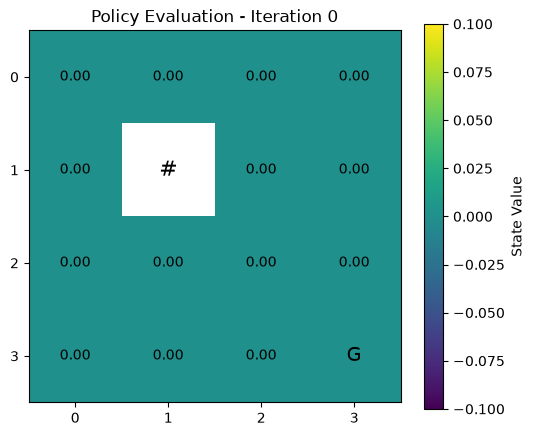

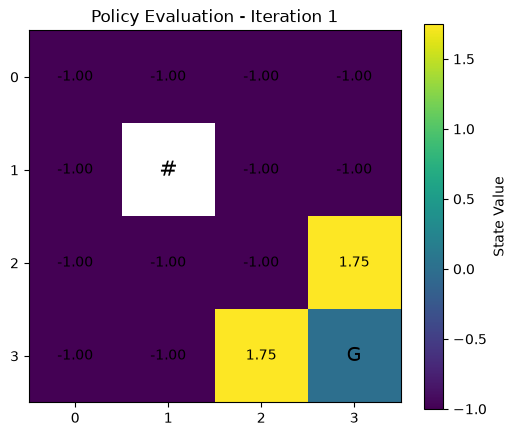

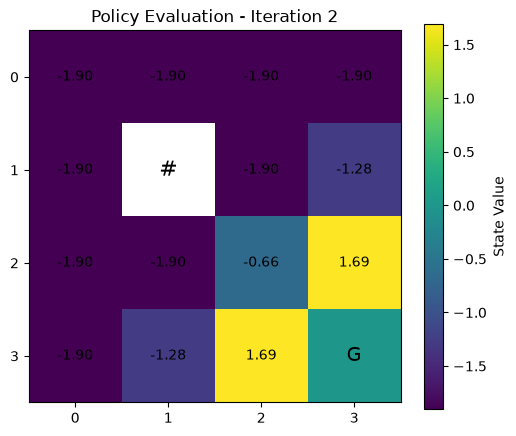

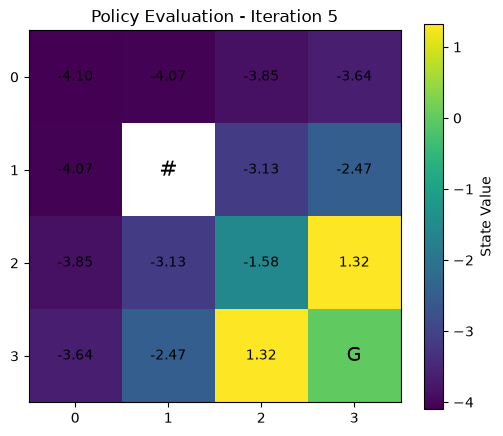

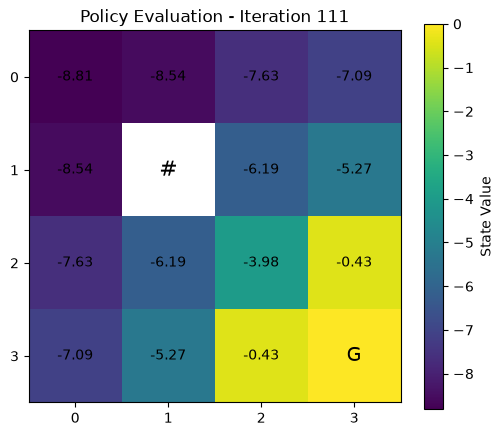

In [5]:
iterations = [
    0,
    1,
    2,
    5,
    len(history) - 1,
]

for i in iterations:
    plot_value_map(
        env,
        history[i],
        title=f"Policy Evaluation - Iteration {i}",
    )

In [9]:
from src.policy_iteration import policy_iteration
from src.value_iteration import value_iteration
values_pi, policy_pi = None, None

policy_pi, values_pi = policy_iteration(
    env,
    gamma=0.9,
    theta=1e-6,
)

values_vi, policy_vi = value_iteration(
    env,
    gamma=0.9,
    theta=1e-6,
)

differences = {
    state: abs(
        values_pi[state]
        - values_vi[state]
    )
    for state in env.get_states()
}

max_difference = max(differences.values())

print(
    "Maximum value difference:",
    max_difference,
)

Maximum value difference: 0.0


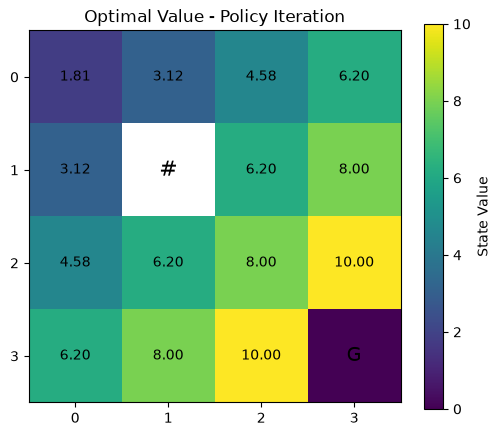

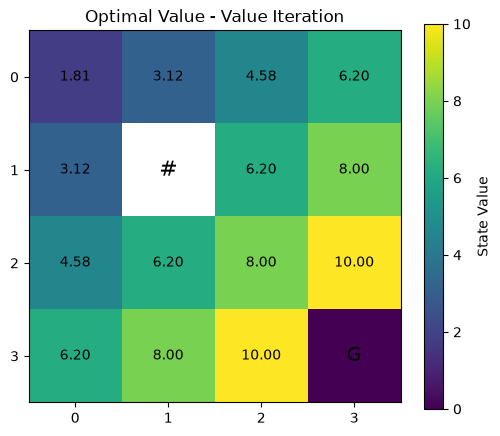

In [10]:
plot_value_map(
    env,
    values_pi,
    title="Optimal Value - Policy Iteration",
)
plot_value_map(
    env,
    values_vi,
    title="Optimal Value - Value Iteration",
)

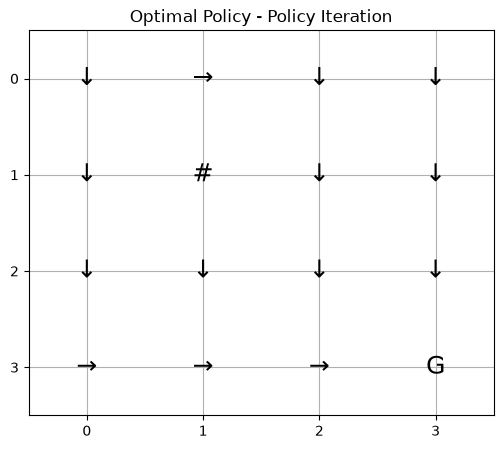

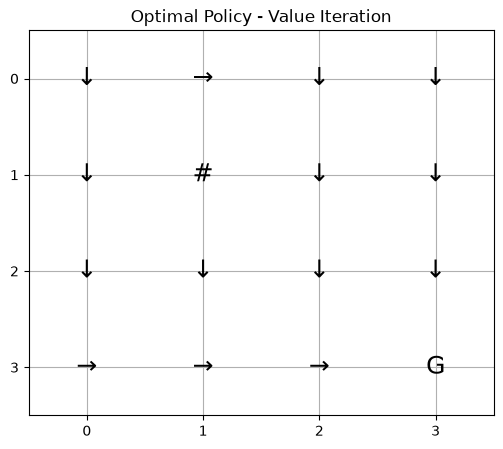

In [11]:
ACTION_SYMBOLS = {
    GridWorld.UP: "↑",
    GridWorld.DOWN: "↓",
    GridWorld.LEFT: "←",
    GridWorld.RIGHT: "→",
}

def plot_policy(env, policy, title="Policy"):
    fig, ax = plt.subplots(figsize=(6, 5))

    ax.set_xlim(-0.5, env.width - 0.5)
    ax.set_ylim(env.height - 0.5, -0.5)

    ax.set_xticks(range(env.width))
    ax.set_yticks(range(env.height))

    ax.grid(True)

    for row in range(env.height):
        for col in range(env.width):

            state = (row, col)

            if state in env.obstacles:
                text = "#"

            elif env.is_terminal(state):
                text = "G"

            else:
                text = ACTION_SYMBOLS[
                    policy[state]
                ]

            ax.text(
                col,
                row,
                text,
                ha="center",
                va="center",
                fontsize=18,
            )

    ax.set_title(title)

    plt.show()
    
plot_policy(
    env,
    policy_pi,
    title="Optimal Policy - Policy Iteration",
)

plot_policy(
    env,
    policy_vi,
    title="Optimal Policy - Value Iteration",
)

In [12]:
gammas = [
    0.0,
    0.5,
    0.9,
    0.99,
]

results = {}

for gamma in gammas:

    values, policy = value_iteration(
        env,
        gamma=gamma,
        theta=1e-6,
    )

    results[gamma] = {
        "values": values,
        "policy": policy,
    }

for gamma in gammas:

    start_value = (
        results[gamma]["values"][
            env.start_state
        ]
    )

    print(
        f"gamma={gamma:>4}: "
        f"V*(start)={start_value:.4f}"
    )

gamma= 0.0: V*(start)=-1.0000
gamma= 0.5: V*(start)=-1.6250
gamma= 0.9: V*(start)=1.8098
gamma=0.99: V*(start)=4.6089


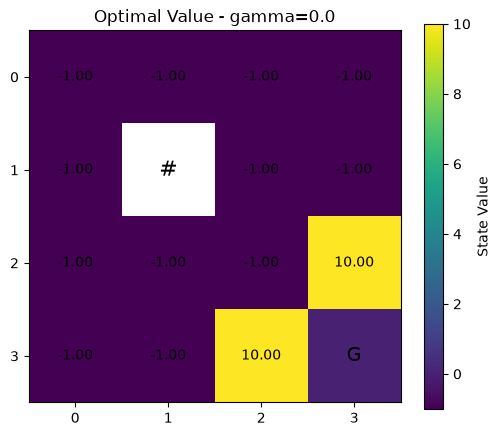

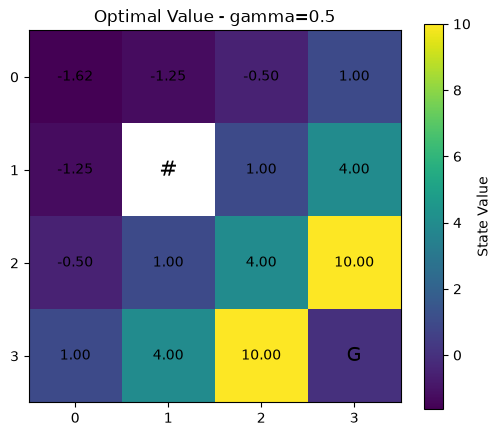

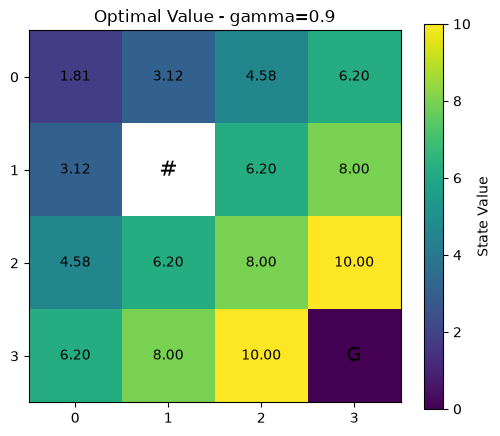

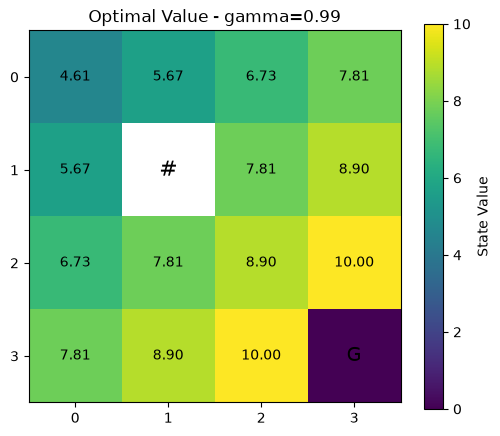

In [13]:
for gamma in gammas:

    plot_value_map(
        env,
        results[gamma]["values"],
        title=f"Optimal Value - gamma={gamma}",
    )

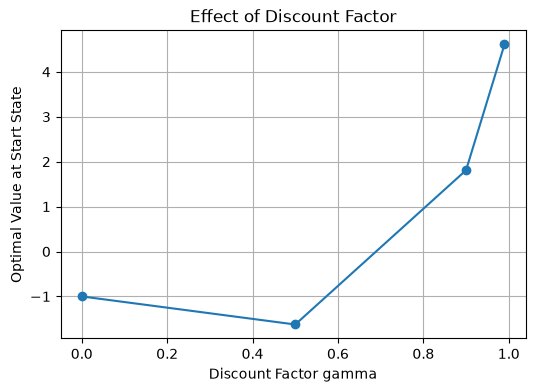

In [14]:
start_values = [
    results[gamma]["values"][
        env.start_state
    ]
    for gamma in gammas
]

plt.figure(figsize=(6, 4))

plt.plot(
    gammas,
    start_values,
    marker="o",
)

plt.xlabel("Discount Factor gamma")
plt.ylabel("Optimal Value at Start State")
plt.title("Effect of Discount Factor")

plt.grid(True)

plt.show()

## 实验结论与提交要求

运行完本 Notebook 后，不要只保留图。请在对应 `notes/` 中记录随机种子、环境版本、关键超参数、最终指标、曲线文件和一个失败现象。结论必须区分“代码运行成功”和“算法表现更好”：前者由自检确认，后者需要多 seed 或控制变量实验支持。

提交前从仓库根目录运行：

```bash
python eval/run.py
```
